In [1]:
# Install Libraries
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

In [3]:
# Connect to MySQL
host = "18.136.157.135"
database = "project_orders"
username = "dm_team20"
password = ")KiC1mip045X"
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
print("Connected Successfully!")

Connected Successfully!


In [4]:
# Load all five tables into Pandas
aisles = pd.read_sql("SELECT * FROM aisles;", engine)
departments = pd.read_sql("SELECT * FROM departments;", engine)
products = pd.read_sql("SELECT * FROM products;", engine)
orders = pd.read_sql("SELECT * FROM orders;", engine)
order_products = pd.read_sql("SELECT * FROM order_products_train;",engine)

In [5]:
# Verify table shapes
print("Aisles:", aisles.shape)
print("Departments:", departments.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order Products:", order_products.shape)

Aisles: (134, 2)
Departments: (21, 2)
Products: (49355, 4)
Orders: (1048575, 7)
Order Products: (1048575, 4)


In [6]:
# Check Column Names & Data Types

print("AISLES")
print(aisles.info())

print("\nDEPARTMENTS")
print(departments.info())

print("\nPRODUCTS")
print(products.info())

print("\nORDERS")
print(orders.info())

print("\nORDER_PRODUCTS")
print(order_products.info())

AISLES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None

DEPARTMENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None

PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49355 entries, 0 to 49354
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49355 non-null  int64 
 1   product_name   49355 non-null  object
 2   aisle_id       49355 non-null  int64 
 3

In [7]:
# Verify Missing Values

tables = {
    "Aisles": aisles,
    "Departments": departments,
    "Products": products,
    "Orders": orders,
    "Order_Products": order_products
}
for name, df in tables.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Aisles
aisle_id    0
aisle       0
dtype: int64

Departments
department_id    0
department       0
dtype: int64

Products
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Orders
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

Order_Products
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [8]:
# Verify Duplicate Records

print("Aisles:", aisles.duplicated().sum())
print("Departments:", departments.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Order Products:", order_products.duplicated().sum())

Aisles: 0
Departments: 0
Products: 0
Orders: 0
Order Products: 0


In [9]:
# Merge the Tables

orders_train = orders[orders["eval_set"] == "train"].copy()

master_df = (
    order_products
    .merge(orders_train, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

print(master_df.shape)
master_df.head()

(318051, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,38,11913,1,0,42756,train,6,6,16,24,Shelled Pistachios,117.0,19.0,nuts seeds dried fruit,snacks
1,38,18159,2,0,42756,train,6,6,16,24,Organic Biologique Limes,123.0,4.0,packaged vegetables fruits,produce
2,38,4461,3,0,42756,train,6,6,16,24,Organic Raw Unfiltered Apple Cider Vinegar,19.0,13.0,oils vinegars,pantry
3,38,21616,4,1,42756,train,6,6,16,24,Organic Baby Arugula,123.0,4.0,packaged vegetables fruits,produce
4,38,23622,5,0,42756,train,6,6,16,24,Organic Hot House Tomato,83.0,4.0,fresh vegetables,produce


In [10]:
# Displays the output neatly

def show(df, rows=10):
    return df.head(rows).reset_index(drop=True)

In [11]:
# QUERY 1 - What are the top 10 aisles with the highest number of products?

q1_top_aisles = (
    products
    .merge(aisles, on="aisle_id")
    .groupby("aisle", as_index=False)
    .agg(total_products=("product_id", "count"))
    .sort_values("total_products", ascending=False)
)

print(show(q1_top_aisles, 10))

# Verify what "missing" actually means
aisles[aisles["aisle"] == "missing"]

                  aisle  total_products
0               missing            1254
1       candy chocolate            1235
2         ice cream ice            1084
3  vitamins supplements            1030
4                yogurt            1023
5        chips pretzels             980
6       packaged cheese             888
7                   tea             887
8          frozen meals             880
9         cookies cakes             869


,aisle_id,aisle
99,100,missing


In [12]:
# QUERY 2 - How many unique departments are there?

q2_department_count = departments["department"].nunique()

print(f"Total Unique Departments: {q2_department_count}")

Total Unique Departments: 21


In [13]:
# QUERY 3 - Distribution of products across departments

q3_department_distribution = (
    products
    .merge(departments, on="department_id")
    .groupby("department", as_index=False)
    .agg(total_products=("product_id", "count"))
    .sort_values("total_products", ascending=False)
)

show(q3_department_distribution)

,department,total_products
0,personal care,6524
1,snacks,6221
2,pantry,5331
3,beverages,4324
4,frozen,3982
5,dairy eggs,3428
6,household,3068
7,canned goods,2073
8,dry goods pasta,1845
9,produce,1671


In [33]:
# QUERY 4 - Top 10 products with highest reorder rates

def top_reorder_products(min_orders):
    result = (
        master_df
        .groupby("product_name", as_index=False)
        .agg(
            total_orders=("product_id", "count"),
            reorder_count=("reordered", "sum")
        )
    )

    result["reorder_rate"] = (
        result["reorder_count"] / result["total_orders"] * 100
    ).round(2)

    result = (
        result[result["total_orders"] >= min_orders]
        .sort_values(
            ["reorder_rate", "total_orders"],
            ascending=[False, False]
        )
        .head(10)
    )

    return result

print("Minimum Orders = 20")
display(top_reorder_products(20))

print("Minimum Orders = 50")
display(top_reorder_products(50))

print("Minimum Orders = 100")
display(top_reorder_products(100))

Minimum Orders = 20


,product_name,total_orders,reorder_count,reorder_rate
658,A+ Cinnamon Sweet Potato Pancakes,21,21,100.00
12449,Maple Honey Ham,23,22,95.65
22070,"Sparkling Water, Bottles",20,19,95.00
22895,Super Natural Organic Whole Milk,20,19,95.00
15943,Organic Low Fat Milk,100,93,93.00
15859,Organic Lactose Free 1% Lowfat Milk,68,63,92.65
5762,Crinkle Cut French Fries,27,25,92.59
25670,Wild Berry Smoothie,50,46,92.00
7975,French Vanilla Coffee Creamer,25,23,92.00
25908,Yogurt Tubes Blueberry,21,19,90.48


Minimum Orders = 50


,product_name,total_orders,reorder_count,reorder_rate
15943,Organic Low Fat Milk,100,93,93.00
15859,Organic Lactose Free 1% Lowfat Milk,68,63,92.65
25670,Wild Berry Smoothie,50,46,92.00
17136,Organic Whole Milk with DHA Omega-3,115,104,90.43
13030,"Milk, Organic, Vitamin D",139,124,89.21
16464,Organic Reduced Fat Milk,274,242,88.32
15961,Organic Lowfat 1% Milk,93,82,88.17
1809,Banana,4357,3840,88.13
8013,Fresh CA Grown Eggs,92,81,88.04
32,1% Lowfat Milk,99,87,87.88


Minimum Orders = 100


,product_name,total_orders,reorder_count,reorder_rate
15943,Organic Low Fat Milk,100,93,93.00
17136,Organic Whole Milk with DHA Omega-3,115,104,90.43
13030,"Milk, Organic, Vitamin D",139,124,89.21
16464,Organic Reduced Fat Milk,274,242,88.32
1809,Banana,4357,3840,88.13
19424,Pure Sparkling Water,258,222,86.05
1689,Bag of Organic Bananas,3522,3016,85.63
17126,Organic Whole Milk,1121,957,85.37
15396,Organic Fat Free Milk,188,160,85.11
15864,Organic Large Brown Grade AA Cage Free Eggs,257,216,84.05


In [15]:
# QUERY 5 - How many unique users have placed orders in the dataset?

q5_unique_users = orders["user_id"].nunique()

print(f"Total Unique Users: {q5_unique_users}")

Total Unique Users: 63100


In [16]:
# QUERY 6 - What is the average number of days between orders for each user?

q6_avg_days_between_orders = (
    orders[orders["days_since_prior_order"].notna()]
    .copy()
    .assign(days_since_prior_order=lambda df: pd.to_numeric(df["days_since_prior_order"]))
    .groupby("user_id", as_index=False)
    .agg(avg_days_between_orders=("days_since_prior_order", "mean"))
)

show(q6_avg_days_between_orders)

,user_id,avg_days_between_orders
0,1,19.000000
1,2,16.285714
2,3,12.000000
3,4,17.000000
4,5,11.500000
5,6,13.333333
6,7,10.450000
7,8,23.333333
8,9,22.000000
9,10,21.800000


    order_hour_of_day  total_orders
10                 10         88228
11                 11         87087
14                 14         86905
15                 15         86888
13                 13         85652
12                 12         84204
16                 16         83421
9                   9         78737
17                 17         69960
18                 18         56284
8                   8         54868
19                 19         43076
20                 20         31735
7                   7         28199
21                 21         23972
22                 22         18824
23                 23         12112
6                   6          9253
0                   0          6881
1                   1          3698
5                   5          2882
2                   2          2312
4                   4          1748
3                   3          1649


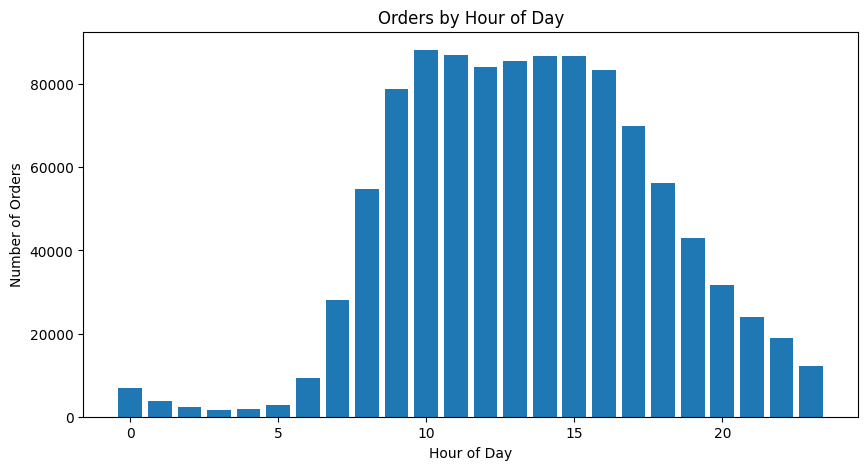

In [17]:
# QUERY 7 - What are the peak hours of order placement during the day?

q7_peak_order_hours = (
    orders
    .groupby("order_hour_of_day", as_index=False)
    .agg(total_orders=("order_id", "count"))
    .sort_values("total_orders", ascending=False)
)

print(q7_peak_order_hours)

# Adding a chart because this is one of the best visuals in the project

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    q7_peak_order_hours["order_hour_of_day"],
    q7_peak_order_hours["total_orders"]
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.show()

,order_dow,total_orders
0,0,183939
1,1,180025
2,2,143162
3,3,133839
4,4,130367
5,5,139183
6,6,138060


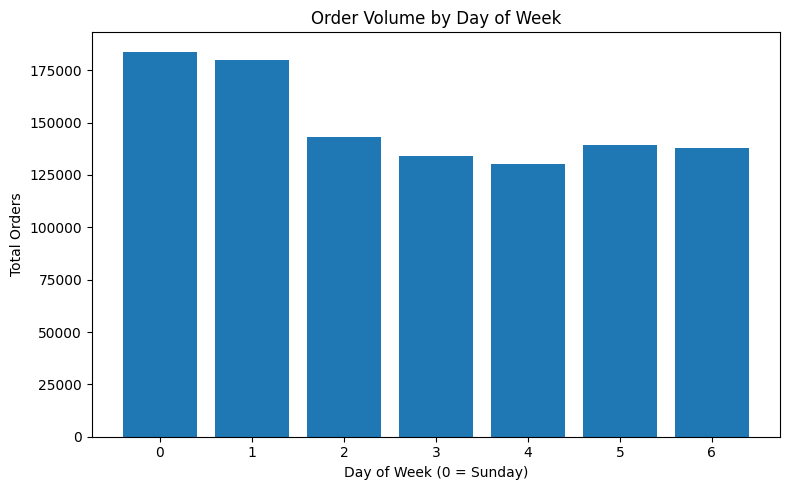

In [18]:
# QUERY 8 - How does order volume vary by day of the week?

import matplotlib.pyplot as plt

q8_orders_by_day = (
    orders
    .groupby("order_dow", as_index=False)
    .agg(total_orders=("order_id", "count"))
    .sort_values("order_dow")
)

display(q8_orders_by_day)

plt.figure(figsize=(8,5))

plt.bar(
    q8_orders_by_day["order_dow"],
    q8_orders_by_day["total_orders"]
)

plt.title("Order Volume by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Total Orders")
plt.xticks(range(7))

plt.tight_layout()
plt.show()

In [19]:
# QUERY 9 - What are the top 10 most ordered products?

q9_top_ordered_products = (
    master_df
    .groupby("product_name", as_index=False)
    .agg(total_orders=("product_id", "count"))
    .sort_values("total_orders", ascending=False)
    .head(10)
)

display(q9_top_ordered_products)

,product_name,total_orders
1809,Banana,4357
1689,Bag of Organic Bananas,3522
16768,Organic Strawberries,2520
14733,Organic Baby Spinach,2286
11392,Large Lemon,1841
15689,Organic Hass Avocado,1705
14706,Organic Avocado,1661
22556,Strawberries,1479
11930,Limes,1383
16388,Organic Raspberries,1279


In [20]:
# QUERY 10 - How many users have placed orders in each department?

q10_users_per_department = (
    master_df
    .groupby("department", as_index=False)
    .agg(unique_users=("user_id", "nunique"))
    .sort_values("unique_users", ascending=False)
)

display(q10_users_per_department)

,department,unique_users
19,produce,22303
7,dairy eggs,20153
3,beverages,14024
20,snacks,13304
10,frozen,11742
16,pantry,10886
2,bakery,8326
8,deli,7430
6,canned goods,6697
9,dry goods pasta,5942


In [21]:
# QUERY 11 - What is the average number of products per order?

q11_avg_products_per_order = (
    master_df
    .groupby("order_id")
    .size()
    .mean()
)

print(f"Average Products per Order: {q11_avg_products_per_order:.2f}")

Average Products per Order: 10.51


In [22]:
# QUERY 12 - Most reordered product in each department

q12_most_reordered = (
    master_df
    .groupby(["department", "product_name"], as_index=False)
    .agg(reorder_count=("reordered", "sum"))
)

q12_most_reordered = (
    q12_most_reordered
    .sort_values(
        ["department", "reorder_count"],
        ascending=[True, False]
    )
    .drop_duplicates("department")
)

display(q12_most_reordered)

,department,product_name,reorder_count
294,alcohol,Sauvignon Blanc,53
435,babies,Baby Food Stage 2 Blueberry Pear & Purple Carrot,44
943,bakery,100% Whole Wheat Bread,412
3921,beverages,Sparkling Water Grapefruit,637
4580,breakfast,Honey Nut Cheerios,167
4999,bulk,Dried Mango,78
5611,canned goods,Organic Black Beans,215
7737,dairy eggs,Organic Whole Milk,957
9086,deli,Original Hummus,539
9849,dry goods pasta,Marinara Sauce,117


In [23]:
# QUERY 13 - Products reordered more than once

q13_products_reordered = (
    master_df
    .groupby("product_name")
    .agg(reorder_count=("reordered", "sum"))
)

q13_products_reordered = (
    q13_products_reordered["reorder_count"] > 1
).sum()

print(f"Products Reordered More Than Once: {q13_products_reordered}")

Products Reordered More Than Once: 11529


In [24]:
# QUERY 14 - Average number of products added to cart per order

q14_avg_cart_size = (
    master_df
    .groupby("order_id")
    .agg(cart_size=("add_to_cart_order", "max"))
)

print(
    f"Average Cart Size: {q14_avg_cart_size['cart_size'].mean():.2f}"
)

Average Cart Size: 10.51


In [25]:
# QUERY 15 - How does the number of orders vary by hour of the day?
# Query 15 is answered using the same analysis as Query 7 because both require the distribution of orders across hours of the day.


q15_order_by_hours = (
    orders
    .groupby("order_hour_of_day", as_index=False)
    .agg(total_orders=("order_id", "count"))
    .sort_values("total_orders", ascending=False)
)

show(q15_order_by_hours)

,order_hour_of_day,total_orders
0,10,88228
1,11,87087
2,14,86905
3,15,86888
4,13,85652
5,12,84204
6,16,83421
7,9,78737
8,17,69960
9,18,56284


In [26]:
# QUERY 16 - Distribution of Order Sizes

q16_order_size_distribution = (
    master_df
    .groupby("order_id")
    .agg(order_size=("product_id", "count"))
    .groupby("order_size", as_index=False)
    .agg(number_of_orders=("order_size", "count"))
    .sort_values("order_size")
)

display(q16_order_size_distribution)

,order_size,number_of_orders
0,1,1536
1,2,1742
2,3,1883
3,4,1890
4,5,2032
...,...,...
62,66,1
63,67,1
64,70,1
65,72,1


In [27]:
# QUERY 17 - Average Reorder Rate by Aisle

q17_avg_reorder_rate = (
    master_df
    .groupby("aisle", as_index=False)
    .agg(avg_reorder_rate=("reordered", "mean"))
)

q17_avg_reorder_rate["avg_reorder_rate"] = (
    q17_avg_reorder_rate["avg_reorder_rate"] * 100
).round(2)

q17_avg_reorder_rate = (
    q17_avg_reorder_rate
    .sort_values("avg_reorder_rate", ascending=False)
)

display(q17_avg_reorder_rate)

,aisle,avg_reorder_rate
83,milk,79.30
131,water seltzer sparkling water,73.97
50,fresh fruits,73.50
41,eggs,73.46
96,packaged produce,70.98
...,...,...
29,cold flu allergy,21.11
8,beauty,20.00
7,baking supplies decor,18.25
122,spices seasonings,17.65


In [28]:
# QUERY 18 - Average Order Size by Day of Week

q18_avg_order_size_by_day = (
    master_df
    .groupby(["order_dow", "order_id"])
    .agg(order_size=("product_id", "count"))
    .reset_index() # Convert index to columns
    .groupby("order_dow", as_index=False)
    .agg(avg_order_size=("order_size", "mean"))
    .sort_values("order_dow")
)

display(q18_avg_order_size_by_day)

,order_dow,avg_order_size
0,0,11.720820
1,1,10.292162
2,2,9.908470
3,3,9.667867
4,4,9.853087
5,5,10.198272
6,6,11.030755


In [29]:
# QUERY 19 - Top 10 Users with Highest Number of Orders

q19_top_users = (
    orders
    .groupby("user_id", as_index=False)
    .agg(total_orders=("order_id", "count"))
    .sort_values("total_orders", ascending=False)
    .head(10)
)

display(q19_top_users)

,user_id,total_orders
15895,15896,100
16289,16290,100
57837,57838,100
57850,57851,100
16297,16298,100
16312,16313,100
16339,16340,100
16356,16357,100
16363,16364,100
963,964,100


In [30]:
# QUERY 20 - Products in Each Aisle and Department

q20_products_by_aisle_department = (
    products
    .merge(aisles, on="aisle_id")
    .merge(departments, on="department_id")
    .groupby(["department", "aisle"], as_index=False)
    .agg(total_products=("product_id", "count"))
    .sort_values(
        ["department", "total_products"],
        ascending=[True, False]
    )
)

display(q20_products_by_aisle_department)

,department,aisle,total_products
0,alcohol,beers coolers,384
1,alcohol,red wines,232
3,alcohol,spirits,192
4,alcohol,white wines,146
2,alcohol,specialty wines champagnes,95
...,...,...,...
128,snacks,fruit vegetable snacks,356
132,snacks,popcorn jerky,315
130,snacks,mint gum,168
129,snacks,ice cream toppings,83


In [31]:
# Export all tables as CSV

aisles.to_csv("aisles.csv", index=False, encoding="utf-8-sig")
departments.to_csv("departments.csv", index=False, encoding="utf-8-sig")
products.to_csv("products.csv", index=False, encoding="utf-8-sig")
orders.to_csv("orders.csv", index=False, encoding="utf-8-sig")
order_products.to_csv("order_products.csv", index=False, encoding="utf-8-sig")

print("CSV files exported successfully.")

CSV files exported successfully.


In [39]:
# Export Master Dataset for Power BI

master_df.to_csv("master_df.csv",index=False, encoding="utf-8-sig")
top_100_products_df.to_csv("top_reorder_products.csv", index=False, encoding="utf-8-sig")
q12_most_reordered.to_csv("most_reordered_by_department.csv", index=False, encoding="utf-8-sig")

print("All 3 files exported successfully.")

All 3 files exported successfully.
